# ME 3300 — Prelab 01 Walkthrough: Data Analysis in Python

**Complete this notebook *before* coming to lab.** It will walk you through the Python skills you will need to complete Lab 01 using an example dataset, so you will be prepared to apply these methods yourself later.

**How this works:**

- Run each code cell in order from top to bottom. Click a cell and press `Shift+Enter` to run it.
- Read the text cells (like this one) — they explain *why* each step works!
- Watch for **🟦 CHECKPOINT** boxes. These call out specific values that you will report in the **Prelab 01 quiz on Canvas**. This lets us know you are ready for lab.
- Don't worry if Jupyter feels unfamiliar, we spend time in class demonstrating how to run notebooks in VS Code before the lab. This walkthrough is your chance to try it yourself.

**Before you start:** you need the `walkthrough_temperature_data.csv` file from Canvas saved in your `ME3300/Lab_01/Data/` folder, and this notebook saved in `ME3300/Lab_01/Code/`. When you open the notebook, click **Select Kernel** (top right) and choose the `.venv` environment from your `ME3300` folder.

## 1. Importing packages

Python itself is a small language. Much of the what we will do in this course will come from four *packages* you installed with `uv`:

| Package | Alias | What we use it for |
|---|---|---|
| `numpy` | `np` | Fast math on arrays of numbers |
| `pandas` | `pd` | Reading data files, working with labeled tables |
| `matplotlib.pyplot` | `plt` | Making figures |
| `scipy.stats` | `stats` | Statistical distributions (Student's t) |

The `import ... as ...` pattern gives each package a short *alias* so you can type `np.mean(...)` instead of `numpy.mean(...)`. These aliases are near universal conventions, so most Python examples you find online will use them.

The `plt.rcParams` lines set the *default* font for every figure in this notebook, so we don't have to repeat it for each plot. Our class standard is Times, 10 pt.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Class-standard text formatting for all figures
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 10

print("Imports successful!")

Imports successful!


## 2. Loading data — two ways

Our example data is a minute of readings from a temperature sensor, stored as a `.csv` (comma-separated values) file. Open `walkthrough_temperature_data.csv` in VS Code and look at it: the first line is a *header* naming each column, and every following line is one measurement.

There are two standard ways to load a CSV in Python, here we will try **both**.

### Method 1: pandas → DataFrame

`pd.read_csv()` returns a **DataFrame**: a table that keeps the column *names* from the header. You refer to data by label, like a spreadsheet.

In [2]:
# Load with pandas. The path is *relative*: '..' means "up one folder"
# (from Code/ up to Lab_01/, then down into Data/).
df = pd.read_csv('../Data/walkthrough_temperature_data.csv')

N = 10
df.head(N)  # show the first N rows. It's wise to always inspect data after loading!

,Time (s),Temp (C)
0,0.5,21.368
1,1.0,21.325
2,1.5,21.048
3,2.0,21.205
4,2.5,20.568
5,3.0,21.281
6,3.5,21.298
7,4.0,21.294
8,4.5,22.017
9,5.0,21.757


In [3]:
print("Type: ", type(df))
print("Shape:", df.shape)   # (rows, columns)
print("Columns:", list(df.columns))

Type:  <class 'pandas.DataFrame'>
Shape: (120, 2)
Columns: ['Time (s)', 'Temp (C)']


### Method 2: NumPy → array

`np.loadtxt()` returns an **array**: a plain grid of numbers with *no* column names. We must tell it that values are separated by commas and that the first row (the header text) should be skipped, NumPy can only hold numbers, so the header would cause an error.

In [4]:
# Load the same file with numpy
arr = np.loadtxt('../Data/walkthrough_temperature_data.csv', delimiter=',', skiprows=1)

print("Type: ", type(arr))
print("Shape:", arr.shape)   # (rows, columns)
print("dtype:", arr.dtype)   # every element is the same numeric type
print("First 3 rows:")
print(arr[:3])

Type:  <class 'numpy.ndarray'>
Shape: (120, 2)
dtype: float64
First 3 rows:
[[ 0.5   21.368]
 [ 1.    21.325]
 [ 1.5   21.048]]


### DataFrame vs. array — the key difference

This is one of the most important ideas in this lab:

| | pandas **DataFrame** | NumPy **array** |
|---|---|---|
| Columns | Named (`df['Temp (C)']`) | Numbered (`arr[:, 1]`) |
| Contents | Can mix numbers, text, dates | One numeric type only |
| Best for | Loading/inspecting/organizing data files | Fast math: statistics, fits, element-wise operations |

They work together: a typical workflow is **load with pandas** (robust, keeps labels), then **extract the columns you need as NumPy arrays** for computation using `.values`:

In [5]:
# Extract each DataFrame column as a plain numpy array
time = df['Time (s)'].values
temp = df['Temp (C)'].values

print(type(df['Temp (C)']))   # a pandas Series (a labeled column)
print(type(temp))             # a numpy array — ready for math

# The numpy load gives the same numbers, just accessed by position:
temp_from_np = arr[:, 1]      # all rows, column index 1
print("pandas and numpy columns match:", np.allclose(temp, temp_from_np))

<class 'pandas.Series'>
<class 'numpy.ndarray'>
pandas and numpy columns match: True


> 🟦 **CHECKPOINT 1 (report on Canvas):**
> 1. How many rows of data are in the file (from `df.shape` or `arr.shape`)?
> 2. In the comparison above, which object type keeps column *names*: the DataFrame or the array?
> 3. What are some pros and cons of each a numpy array vs a pandas dataframe?

## 3. Indexing and slicing arrays

Python counts from **zero**: the *first* element of `temp` is `temp[0]`, so the *50th* data point is `temp[49]`.

A *slice* `temp[a:b]` gives elements starting at index `a` and stopping **before** index `b`. So data points 4 through 8 (the 4th, 5th, 6th, 7th, 8th values) are `temp[3:8]`.

In [6]:
print("1st data point:  temp[0]  =", temp[0])
print("50th data point: temp[49] =", temp[49])
print("Points 4-8:      temp[3:8] =", temp[3:8])
print("Last data point: temp[-1] =", temp[-1])   # negative indices count from the end

# Slices work on 2D arrays too: arr[rows, columns]
print("Rows 4-8 of the full array:")
print(arr[3:8, :])

1st data point:  temp[0]  = 21.368
50th data point: temp[49] = 20.859
Points 4-8:      temp[3:8] = [21.205 20.568 21.281 21.298 21.294]
Last data point: temp[-1] = 21.567
Rows 4-8 of the full array:
[[ 2.    21.205]
 [ 2.5   20.568]
 [ 3.    21.281]
 [ 3.5   21.298]
 [ 4.    21.294]]


> 🟦 **CHECKPOINT 2 (report on Canvas):**
> 1. What is the value of the **31st** temperature data point?

## 4. Descriptive statistics with NumPy

NumPy provides all the basic statistics you need. One subtlety matters: **`ddof=1`**.

`ddof` stands for *delta degrees of freedom*. The standard deviation formula divides by $N - \text{ddof}$:

- `ddof=0` (NumPy's default) divides by $N$ → the **population** standard deviation. Use this only when your data is the *entire* population.
- `ddof=1` divides by $N-1$ → the **sample** standard deviation. Our measurements are a *sample* of all values the sensor could produce, so **in this course we almost always use `ddof=1`**. (This matches the $s_x$ formula from lecture and from your textbook.)

With $N=120$ points the difference is small, but this principle matters more with smaller sample sizes (and it gets checked on exams :P).

In [7]:
t_mean   = np.mean(temp)
t_median = np.median(temp)
t_std    = np.std(temp, ddof=1)   # sample standard deviation
t_var    = np.var(temp, ddof=1)   # sample variance

print(f"Mean:               {t_mean:.4f} C")
print(f"Median:             {t_median:.4f} C")
print(f"Sample std (ddof=1): {t_std:.4f} C")
print(f"Sample var (ddof=1): {t_var:.4f} C^2")
print(f"Population std (ddof=0): {np.std(temp, ddof=0):.4f} C   <- slightly smaller")

Mean:               21.2483 C
Median:             21.2410 C
Sample std (ddof=1): 0.3487 C
Sample var (ddof=1): 0.1216 C^2
Population std (ddof=0): 0.3472 C   <- slightly smaller


> 🟦 **CHECKPOINT 3 (report on Canvas):**
> 1. The mean temperature to (6 decimal places).
> 2. The **sample** standard deviation with `ddof=1` (6 decimal places).
> 3. In one sentence: why do we use `ddof=1` for experimental data?

## 5. Building a publication-quality figure

Matplotlib figures have two parts you will use constantly:

- The **Figure** (`fig`) — the whole canvas. Controls size, background, and saving.
- The **Axes** (`ax`) — one plot area on that canvas. Controls the data, labels, grid, and limits.

`plt.subplots()` creates both at once. Then every plotting command is a *method* of `ax`. This "object-oriented" style is what you'll use all semester.

Below we build a scatter plot of the temperature data with horizontal lines at the mean and at ±1 standard deviation. Exactly the kind of figure you'll make from your own voltage data in lab.

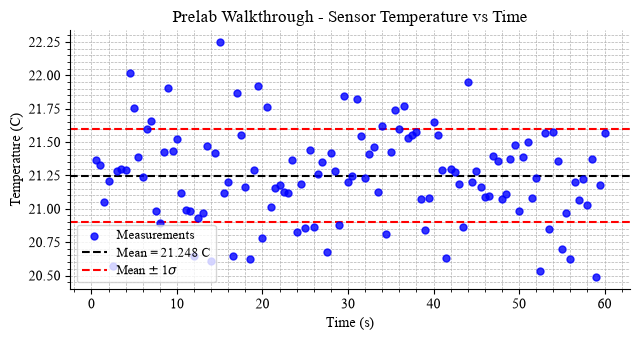

In [8]:
fig1, ax1 = plt.subplots(figsize=(6.5, 3.5))    # size in inches: class standard 6.5 x 3.5
fig1.patch.set_facecolor('white')

# The data: markers only, no connecting lines (it's sampled data!)
ax1.scatter(time, temp, color='blue', s=25, alpha=0.8, zorder=3, label='Measurements')

# Reference lines: mean (black) and mean +/- 1 std (red)
ax1.axhline(t_mean, color='black', linewidth=1.5, linestyle='--',
            label=f'Mean = {t_mean:.3f} C')
ax1.axhline(t_mean + t_std, color='red', linewidth=1.5, linestyle='--',
            label=rf'Mean $\pm$ 1$\sigma$')
ax1.axhline(t_mean - t_std, color='red', linewidth=1.5, linestyle='--')

# Labels, grid, and cleanup — required formatting in this class
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Temperature (C)')
ax1.set_title("Prelab Walkthrough - Sensor Temperature vs Time")
ax1.legend(loc='lower left', fontsize=9)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.minorticks_on()
ax1.spines['top'].set_visible(False)     # remove top border
ax1.spines['right'].set_visible(False)   # remove right border
plt.tight_layout()
plt.show()

### Saving figures

`fig.savefig()` writes the figure to a file. In this class you always save **both** formats at **600 DPI**:

- **.pdf** — vector format, for Canvas submissions
- **.png** — raster format with transparency, for inserting into reports and slides

DPI (dots per inch) sets the resolution of raster output. 600 DPI keeps text crisp when the figure is printed or zoomed; low DPI (72–150) makes smaller files for quick drafts but looks fuzzy in print.

In [9]:
fig1.savefig('../Figures/Prelab01_Walkthrough_Scatter.pdf', dpi=600, bbox_inches='tight')
fig1.savefig('../Figures/Prelab01_Walkthrough_Scatter.png', dpi=600, bbox_inches='tight')
print("Saved! Check your Lab_01/Figures folder.")

Saved! Check your Lab_01/Figures folder.


## 6. Histograms

A histogram shows how values are *distributed* by sorting them into bins and counting. There are two choices that matter here:

- **`bins`** — how many bars. Too few hides the shape; too many looks noisy. For our data sizes, 10–40 works well.
- **`density`** — with `density=False` (default) the y-axis is a raw **count**; with `density=True` the histogram is normalized so its total area equals 1, making the y-axis a **probability density** you can compare directly against a theoretical PDF curve. You will use `density=True` in Part 3 of the lab.

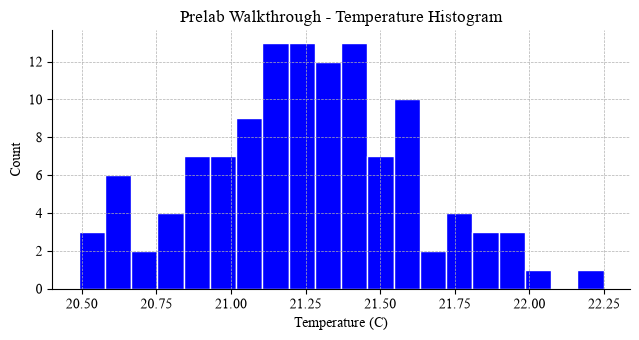

In [10]:
fig2, ax2 = plt.subplots(figsize=(6.5, 3.5))
fig2.patch.set_facecolor('white')

ax2.hist(temp, bins=20, color='blue', edgecolor='white')

ax2.set_xlabel('Temperature (C)')
ax2.set_ylabel('Count')
ax2.set_title("Prelab Walkthrough - Temperature Histogram")
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Try it: re-run this cell with bins=5, then bins=60. What changes?

## 7. Linear curve fits and confidence intervals

Now a new mini-experiment: a spring was stretched to seven displacements $x$ and the force $F$ was measured. We expect $F = kx + b$ (Hooke's law), so a **degree-1 (linear) polynomial fit** finds the spring constant $k$.

Two NumPy functions do the work:

- `np.polyfit(x, y, 1)` returns the fit coefficients `[slope, intercept]`
- `np.polyval(coeffs, x)` evaluates the fitted line at any $x$ values

In [11]:
# Spring calibration data (typed in directly as numpy arrays)
disp  = np.array([0.0,   5.0,   10.0,   15.0,   20.0,   25.0,   30.0])    # mm
force = np.array([1.683, 4.976, 10.150, 14.364, 16.729, 21.219, 26.177])  # N

coeffs = np.polyfit(disp, force, 1)      # [slope, intercept]
force_fit = np.polyval(coeffs, disp)     # fitted F at each measured x

print(f"Slope (spring constant k): {coeffs[0]:.4f} N/mm")
print(f"Intercept (preload):       {coeffs[1]:.4f} N")

Slope (spring constant k): 0.8039 N/mm
Intercept (preload):       1.5554 N


### How good is the fit? The standard error of the fit

The scatter of the data about the fitted line is measured by the **standard error of the fit**:

$$s_{yx} = \sqrt{\frac{\sum_{i=1}^{N}(y_i - y_{c_i})^2}{\nu}}$$

where $y_i$ are the measurements, $y_{c_i}$ are the fitted values, and $\nu$ is the **degrees of freedom**. A linear fit estimates *two* parameters (slope and intercept) from the data, so $\nu = N - 2$. Larger $s_{yx}$ = more scatter about the line.

In [12]:
N  = len(force)
nu = N - 2                       # linear fit estimates 2 parameters -> N - 2
residuals = force - force_fit    # measurement minus fit, point by point

# todo: implement the standard error of the fit calculation correctly
#       Hint you will want to use np.sqrt() & np.sum() and ** to square the residuals, then divide by nu.
s_yx =  0 # replace with the correct calculation of the standard error of the fit

print(f"N = {N}, degrees of freedom nu = {nu}")
print(f"Standard error of fit s_yx = {s_yx:.4f} N")

N = 7, degrees of freedom nu = 5
Standard error of fit s_yx = 0.0000 N


### The t-value: reading a t-table with `scipy` — read this carefully!

To draw a 95% confidence band we need the Student's t-value $t_{\nu,95}$ — the same number you look up in the t-table in your textbook. In Python it comes from `stats.t.ppf()`, and here is where **almost everyone makes the same mistake**.

`ppf` is the *percent point function*: `stats.t.ppf(q, df)` returns the t-value with **cumulative probability `q` below it** — i.e., area `q` in ONE tail direction. But a 95% *confidence interval* is **two-sided**: the 5% of excluded probability is split between the two tails, 2.5% in each.

$$q = 1 - \frac{\alpha}{2} = 1 - \frac{0.05}{2} = 0.975$$

So for a 95% CI you call `stats.t.ppf(0.975, df=nu)` — **not** `ppf(0.95)`, which would leave the whole 5% in one tail and actually gives you a 90% two-sided interval.

**Check yourself against the table:** your textbook's t-table says $t_{\nu=5,\,95\%} = 2.571$. Run the cell below and see which call reproduces it.

In [13]:
t_wrong = stats.t.ppf(0.95, df=nu)    # one-tailed 95% -> only a 90% CI. Common mistake!
t_val   = stats.t.ppf(0.975, df=nu)   # correct for a two-sided 95% CI

print(f"stats.t.ppf(0.95,  df=5) = {t_wrong:.4f}   <- does NOT match the t-table's 95% column")
print(f"stats.t.ppf(0.975, df=5) = {t_val:.4f}   <- matches the table value 2.571")

# The 95% confidence band on the fit:
CI = t_val * s_yx                     # half-width of the confidence interval
print(f"95% CI half-width = {CI:.4f} N")

stats.t.ppf(0.95,  df=5) = 2.0150   <- does NOT match the t-table's 95% column
stats.t.ppf(0.975, df=5) = 2.5706   <- matches the table value 2.571
95% CI half-width = 0.0000 N


### Uncertainty of the slope

Since the slope *is* our spring constant, we also want its standard error:

$$S_{a_1} = s_{yx}\sqrt{\frac{1}{\sum_{i=1}^{N}(x_i - \bar{x})^2}}$$

Note its units: it has the units of the **slope** (here N/mm), because it describes uncertainty in the slope.

In [15]:
# todo: implement the standard error of the slope calculation correctly
#   hint you will want to use np.sqrt(), np.sum(), np.mean(), and **.
S_a1 = 0 # replace with the correct calculation of the standard error of the slope

print(f"Standard error of the slope S_a1 = {S_a1:.5f} N/mm")
print(f"Report the spring constant as: k = {coeffs[0]:.3f} +/- {t_val*S_a1:.3f} N/mm (95%)")

Standard error of the slope S_a1 = 0.00000 N/mm
Report the spring constant as: k = 0.804 +/- 0.000 N/mm (95%)


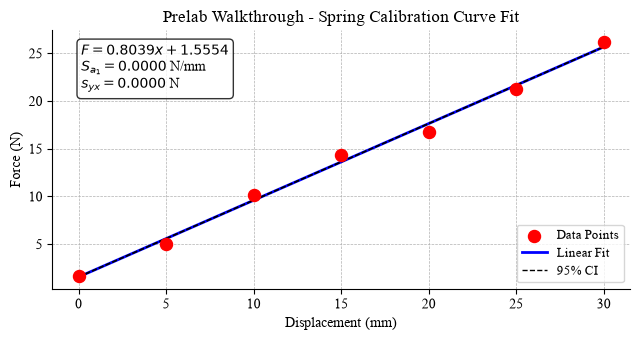

In [16]:
# Put it all together on one figure
x_line = np.linspace(disp.min(), disp.max(), 200)   # dense x values for smooth lines
fit_line = np.polyval(coeffs, x_line)

fig3, ax3 = plt.subplots(figsize=(6.5, 3.5))
fig3.patch.set_facecolor('white')

ax3.scatter(disp, force, color='red', s=75, zorder=5, label='Data Points')
ax3.plot(x_line, fit_line, color='blue', linewidth=2, label='Linear Fit')
ax3.plot(x_line, fit_line + CI, color='black', linewidth=1, linestyle='--', label='95% CI')
ax3.plot(x_line, fit_line - CI, color='black', linewidth=1, linestyle='--')

# Annotate with the fit equation and errors. Units: s_yx has y units (N);
# S_a1 has slope units (N/mm).
fit_label = (f'$F = {coeffs[0]:.4f}x + {coeffs[1]:.4f}$\n'
             f'$S_{{a_1}} = {S_a1:.4f}$ N/mm\n'
             f'$s_{{yx}} = {s_yx:.4f}$ N')
ax3.text(0.05, 0.95, fit_label, transform=ax3.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax3.set_xlabel('Displacement (mm)')
ax3.set_ylabel('Force (N)')
ax3.set_title('Prelab Walkthrough - Spring Calibration Curve Fit')
ax3.legend(loc='lower right', fontsize=9)
ax3.grid(True, which='both', linestyle='--', linewidth=0.5)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

> 🟦 **CHECKPOINT 4 (report on Canvas):**
> 1. The slope (spring constant) from `np.polyfit`, 4 decimal places.
> 2. The standard error of the fit $s_{yx}$, 4 decimal places.
> 3. The t-value for a 95% CI with $\nu = 5$ (4 decimal places) — and which `ppf` argument (0.95 or 0.975) produced it.
> 4. The standard error of the slope $S_{a_1}$, 5 decimal places.

## 8. Generating synthetic data and the normal PDF

In Part 3 of the lab you'll *create* normally-distributed data instead of measuring it. `np.random.randn(N)` draws $N$ samples from the **standard normal** distribution ($\mu = 0$, $\sigma = 1$). To get any other mean and spread, scale and shift it:

$$x = \mu + \sigma \cdot \texttt{randn}(N)$$

The theoretical curve those samples follow is the normal **probability density function (PDF)**:

$$p(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left[-0.5\left(\frac{x - \mu}{\sigma}\right)^2\right]$$

We fix the random *seed* below so everyone gets the same numbers — that's how your checkpoint can be graded. (In the lab you will not seed, so your figures will differ slightly from your neighbor's. That's expected!)

In [17]:
np.random.seed(3300)               # fixed seed: makes "random" numbers reproducible
mu, sigma = 5.0, 1.5
data = mu + sigma * np.random.randn(1000)   # 1000 samples with mean 5, std 1.5

print(f"Sample mean: {np.mean(data):.4f}   (target was {mu})")
print(f"Sample std:  {np.std(data, ddof=1):.4f}   (target was {sigma})")

Sample mean: 5.0150   (target was 5.0)
Sample std:  1.4906   (target was 1.5)


Note the sample statistics are *close to* but not *exactly* the targets — 1000 random samples never match the true population perfectly. That gap between sample and population is a theme we'll return to all semester.

Now define the PDF as a reusable **function** and compare it to a normalized histogram of the samples:

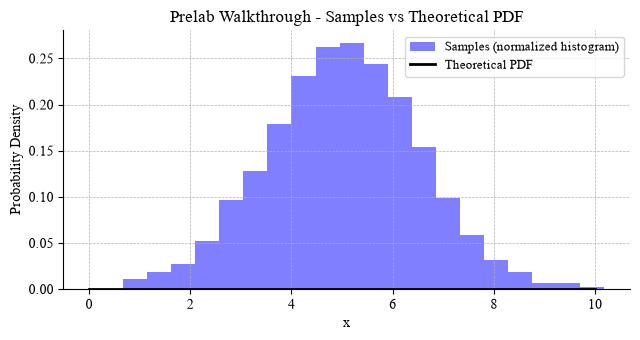

In [20]:
def normal_pdf(x, mu, sigma):
    """Evaluate the normal probability density function at x."""
    #todo: implement the normal PDF formula correctly
    # hint: use np.sqrt(), np.pi, and np.exp(), and **.
    p_x = np.zeros(x.size) # <-- replace with the correct calculation
    return p_x

x_pdf = np.linspace(0, 10, 500)    # 500 evenly spaced x values

fig4, ax4 = plt.subplots(figsize=(6.5, 3.5))
fig4.patch.set_facecolor('white')

# density=True normalizes the histogram so it's comparable to the PDF curve
ax4.hist(data, bins=20, density=True, color='blue', alpha=0.5,
         label='Samples (normalized histogram)')
ax4.plot(x_pdf, normal_pdf(x_pdf, mu, sigma), color='black', linewidth=2,
         label='Theoretical PDF')

ax4.set_xlabel('x')
ax4.set_ylabel('Probability Density')
ax4.set_title('Prelab Walkthrough - Samples vs Theoretical PDF')
ax4.legend(fontsize=9)
ax4.grid(True, linestyle='--', linewidth=0.5)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

> 🟦 **CHECKPOINT 5 (Post your plot on Canvas):**
When you have implemented the formula correctly your theoretical line will match the underlying histogram.

## 9. You're ready for Lab 01

Everything in the lab maps onto what you just did:

| Lab task | You practiced it in |
|---|---|
| Load your voltage CSV with pandas *and* numpy | Section 2 |
| Find dataset size, inspect specific points | Sections 2–3 |
| Mean, median, std, variance (`ddof=1`) | Section 4 |
| Formatted scatter + mean/std lines, save PDF & PNG at 600 DPI | Section 5 |
| Histogram of your voltage data | Section 6 |
| Linear fit + 95% CI + slope error (velocity–voltage data) | Section 7 |
| Synthetic datasets + PDF curves | Section 8 |

**Before lab:** submit your checkpoint values in the Prelab 01 quiz on Canvas, and bring this notebook (and your questions!) to class.